In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
TOP_N = 10
WINDOW_SIZE = 60
DATA_BASE_PATH = Path("./data")

In [7]:
gold_file_path = DATA_BASE_PATH / "final_gold_data.csv"

In [8]:
gold = pd.read_csv(gold_file_path, sep=";", encoding="utf-8", parse_dates=["timestamp"])
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...


In [5]:
gold.describe()

,timestamp,open,high,low,close,volume
count,6177,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000
mean,2012-12-29 00:01:09.936862464,1181.017241,1186.953392,1174.885090,1181.012304,4298.049377
min,2000-08-30 00:00:00,255.000000,256.100000,255.000000,255.100000,0.000000
25%,2006-11-09 00:00:00,636.500000,640.200000,634.000000,635.200000,21.000000
50%,2012-12-31 00:00:00,1238.200000,1243.900000,1231.800000,1238.400000,108.000000
75%,2019-02-25 00:00:00,1641.300000,1652.200000,1630.400000,1640.300000,415.000000
max,2025-04-14 00:00:00,3215.500000,3235.000000,3194.500000,3222.200000,386334.000000
std,NaN,606.257425,609.741360,602.902334,606.424369,24281.911885


In [6]:
gold.sort_values("timestamp", ascending=True, inplace=True)

In [7]:
gold["currency"].value_counts()

currency
usd    6177
Name: count, dtype: int64

In [8]:
gold["unit"].value_counts()

unit
ounce    6177
Name: count, dtype: int64

In [9]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  6177 non-null   datetime64[ns]
 1   open       6177 non-null   float64       
 2   high       6177 non-null   float64       
 3   low        6177 non-null   float64       
 4   close      6177 non-null   float64       
 5   volume     6177 non-null   int64         
 6   currency   6177 non-null   object        
 7   unit       6177 non-null   object        
 8   headlines  6177 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 434.4+ KB


In [10]:
gold["day_variation"] = gold["open"] - gold["close"]
gold["max_diff"] = gold["high"] - gold["low"]

In [11]:
gold[["day_variation", "max_diff"]].describe()

,day_variation,max_diff
count,6177.000000,6177.000000
mean,0.004938,12.068302
std,12.019223,13.161586
min,-90.700000,-1.300000
25%,-4.000000,2.500000
50%,0.000000,9.100000
75%,3.400000,17.100000
max,117.600000,149.400000


array([[<Axes: title={'center': 'day_variation'}>,
        <Axes: title={'center': 'max_diff'}>]], dtype=object)

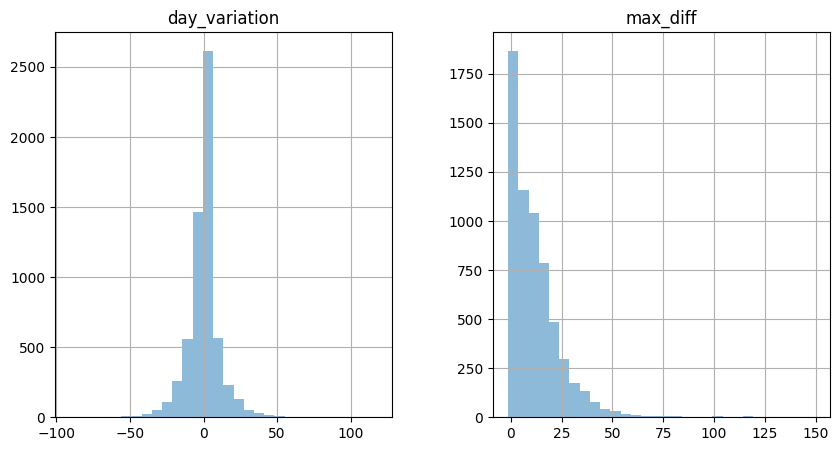

In [12]:
gold[["day_variation", "max_diff"]].hist(bins=30, alpha=0.5, figsize=(10, 5))

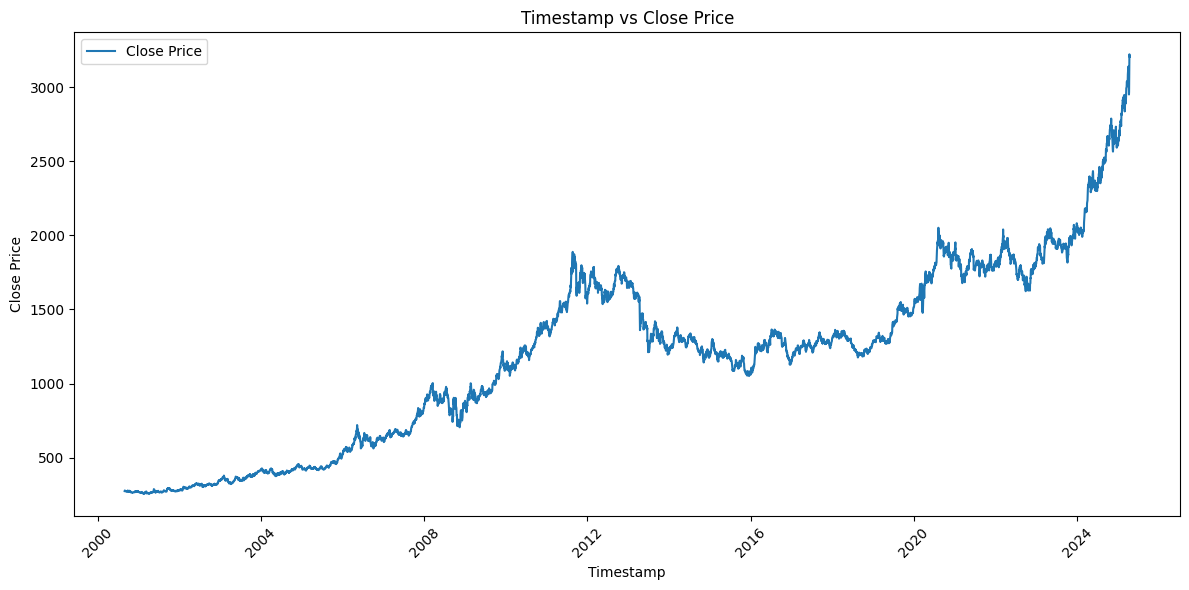

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(gold["timestamp"], gold["close"], label="Close Price")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.title("Timestamp vs Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>],
       [<Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>]], dtype=object)

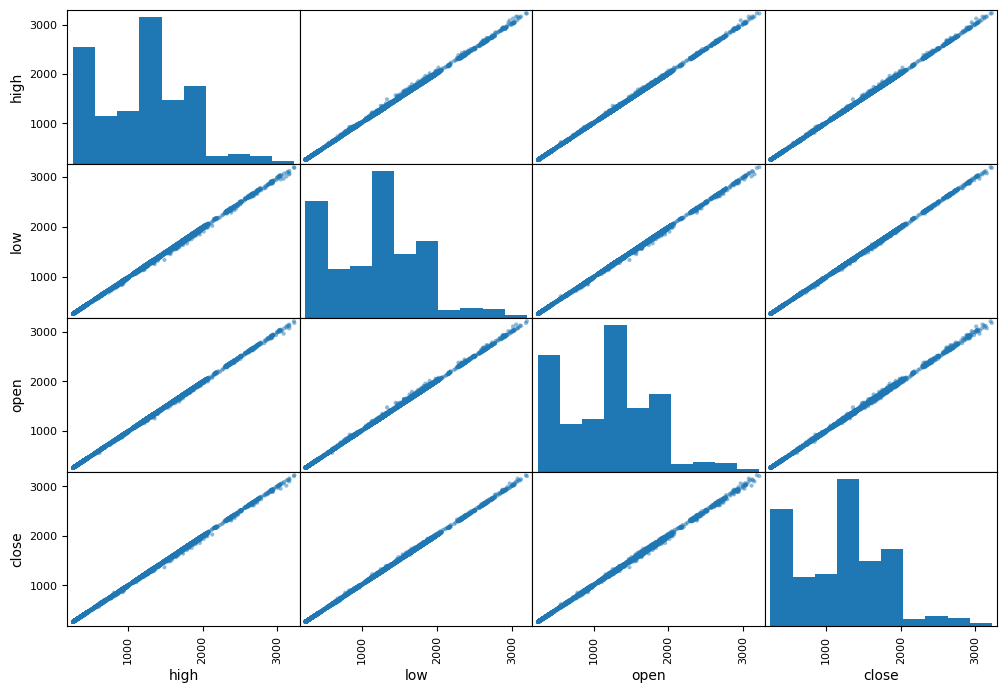

In [14]:
price_cols = ["high", "low", "open", "close"]
scatter_matrix(gold[price_cols], figsize=(12, 8))

In [15]:
gold[price_cols].corr()

,high,low,open,close
high,1.000000,0.999828,0.999906,0.999891
low,0.999828,1.000000,0.999872,0.999916
open,0.999906,0.999872,1.000000,0.999804
close,0.999891,0.999916,0.999804,1.000000


In [16]:
pca = PCA(n_components=1)
gold["price_pca"] = pca.fit_transform(gold[["high", "low", "open", "close"]])
gold["price_pca"].head()

0   -1814.153612
1   -1808.843535
2   -1807.953661
3   -1810.353642
4   -1813.553617
Name: price_pca, dtype: float64

In [17]:
gold["price_pca"].describe()

count    6.177000e+03
mean     1.507726e-13
std      1.212613e+03
min     -1.850300e+03
25%     -1.090683e+03
50%      1.144310e+02
75%      9.199156e+02
max      4.059896e+03
Name: price_pca, dtype: float64

array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='price_pca', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='price_pca', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='price_pca', ylabel='open'>],
       [<Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='price_pca', ylabel='close'>],
       [<Axes: xlabel='high', ylabel='price_pca'>,
     

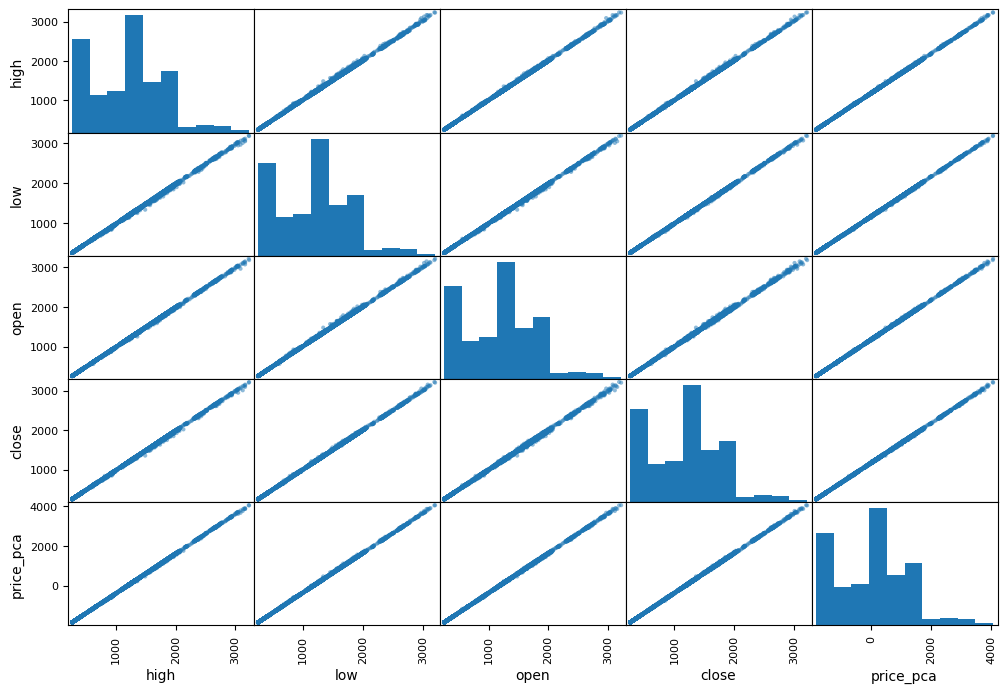

In [18]:
scatter_matrix(gold[price_cols + ["price_pca"]], figsize=(12, 8))

In [19]:
gold.tail(100)

,timestamp,open,high,low,close,volume,currency,unit,headlines,day_variation,max_diff,price_pca
6077,2024-11-19,2621.9,2627.7,2619.3,2627.1,87,usd,ounce,Trump Picks Howard Lutnick as Commerce Secreta...,-5.2,8.4,2886.033042
6078,2024-11-20,2638.5,2648.2,2638.5,2648.2,27,usd,ounce,Ethics Committee Declines to Release Matt Gaet...,-9.7,9.7,2924.736705
6079,2024-11-21,2659.3,2672.1,2655.7,2672.1,33,usd,ounce,Google Should Be Forced to Sell Chrome Browser...,-12.8,16.4,2967.655504
6080,2024-11-22,2687.5,2710.5,2685.6,2709.9,41,usd,ounce,"Trump Picks Russell Vought, a Project 2025 Aut...",-22.4,24.9,3034.829608
6081,2024-11-25,2689.4,2689.4,2616.8,2616.8,94,usd,ounce,"Trump Pledges Tariffs on Mexico, Canada and Ch...",72.6,72.6,2944.408162
...,...,...,...,...,...,...,...,...,...,...,...,...
6172,2025-04-08,2994.0,3014.5,2968.4,2968.4,3213,usd,ounce,South Korea Announces Emergency Support for Au...,25.6,46.1,3610.781296
6173,2025-04-09,2965.8,3090.4,2965.8,3056.5,2175,usd,ounce,Inside the Chinese City That Said Cash Rewards...,-90.7,124.6,3677.610311
6174,2025-04-10,3073.9,3167.0,3072.1,3155.2,3456,usd,ounce,Six Dead in Helicopter Crash in Hudson River N...,-81.3,94.9,3872.374474
6175,2025-04-11,3182.1,3235.0,3182.1,3222.2,862,usd,ounce,Spanish Siemens Couple Killed Alongside Childr...,-40.1,52.9,4048.851674


In [20]:
gold["tomorrow_close"] = gold["close"].shift(-30)
gold = gold.dropna(subset=["tomorrow_close"])  # Remove last row with NaN

<Axes: >

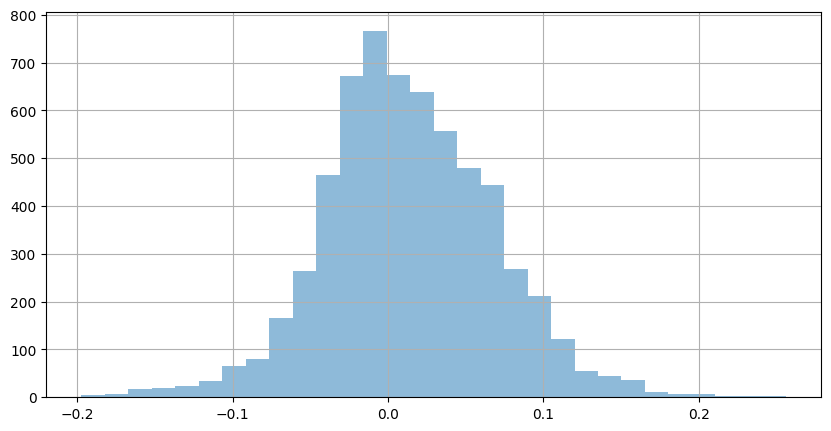

In [ ]:
gold["return"] = (gold["tomorrow_close"] - gold["close"]) / gold[
    "close"
]  # return might be our target
gold["return"].hist(bins=30, alpha=0.5, figsize=(10, 5))

In [22]:
value_cols = price_cols + ["return", "max_diff", "day_variation"]

gold[value_cols].describe()

,high,low,open,close,return,max_diff,day_variation
count,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000
mean,1177.874947,1165.964845,1172.044038,1172.012754,0.013291,11.910102,0.031284
std,597.147225,590.631254,593.904550,593.993870,0.054814,12.798921,11.752330
min,256.100000,255.000000,255.000000,255.100000,-0.197478,-1.300000,-73.500000
25%,636.550000,632.050000,634.650000,633.800000,-0.021777,2.450000,-4.000000
50%,1242.800000,1229.500000,1236.200000,1236.200000,0.009890,9.000000,0.000000
75%,1641.600000,1619.850000,1629.250000,1628.400000,0.049393,17.000000,3.400000
max,2957.900000,2933.100000,2949.100000,2947.900000,0.256195,149.400000,117.600000


array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='return', ylabel='high'>,
        <Axes: xlabel='max_diff', ylabel='high'>,
        <Axes: xlabel='day_variation', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='return', ylabel='low'>,
        <Axes: xlabel='max_diff', ylabel='low'>,
        <Axes: xlabel='day_variation', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='return', ylabel='open'>,
        <Axes: xlabel='max_diff', ylabel='open'>,
        <Axes: xlabel='day_variation', ylabel='op

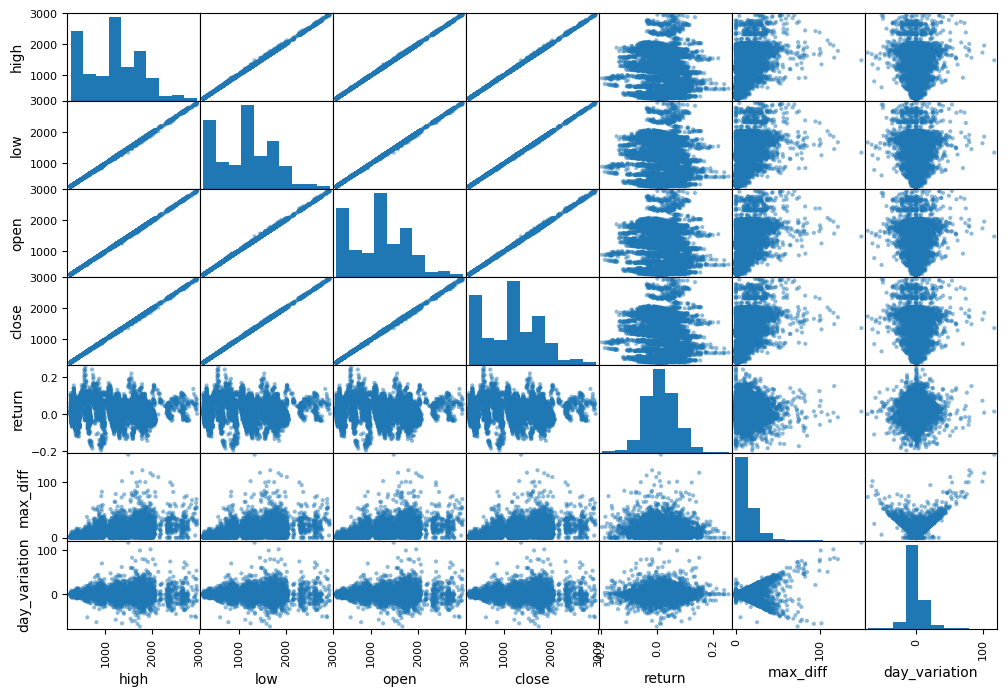

In [23]:
scatter_matrix(gold[value_cols], figsize=(12, 8))

In [24]:
gold[value_cols].corr()

,high,low,open,close,return,max_diff,day_variation
high,1.000000,0.999828,0.999908,0.999891,-0.065778,0.517042,-0.006756
low,0.999828,1.000000,0.999871,0.999916,-0.065405,0.501076,-0.009862
open,0.999908,0.999871,1.000000,0.999804,-0.065522,0.510771,0.002293
close,0.999891,0.999916,0.999804,1.000000,-0.065908,0.507926,-0.017492
return,-0.065778,-0.065405,-0.065522,-0.065908,1.000000,-0.050687,0.019970
max_diff,0.517042,0.501076,0.510771,0.507926,-0.050687,1.000000,0.139885
day_variation,-0.006756,-0.009862,0.002293,-0.017492,0.019970,0.139885,1.000000


count    6147.000000
mean       13.663088
std         6.860841
min         1.000000
25%         8.000000
50%        13.000000
75%        18.000000
max        35.000000
Name: headlines_count, dtype: float64

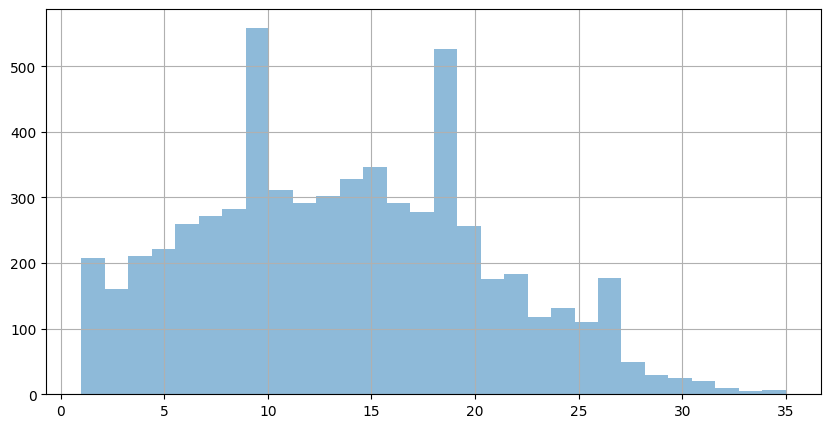

In [25]:
gold["headlines_count"] = gold["headlines"].apply(lambda x: len(x.split("/")))
gold["headlines_count"].hist(bins=30, alpha=0.5, figsize=(10, 5))
gold["headlines_count"].describe()

In [26]:
variances = gold.select_dtypes(include=["float64", "int64"]).var()
for var in variances.index:
    print(f"{var}: {variances[var]:.2f}")

open: 352722.61
high: 356584.81
low: 348845.28
close: 352828.72
volume: 589977805.73
day_variation: 138.12
max_diff: 163.81
price_pca: 1410843.43
tomorrow_close: 365500.79
return: 0.00
headlines_count: 47.07


In [ ]:
def normalize(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std()


def min_max_scaling(series: pd.Series) -> pd.Series:
    return (series - series.min()) / (series.max() - series.min())


def log_normalize(series: pd.Series) -> pd.Series:
    return np.log(series.abs() + 1)  # Adding 1 to avoid log(0)


def log_min_max_scaling(series: pd.Series) -> pd.Series:
    return (np.log(series + 1) - np.log(series.min() + 1)) / (
        np.log(series.max() + 1) - np.log(series.min() + 1)
    )  # Adding 1 to avoid log(0)

In [28]:
gold["volume"].var(), log_normalize(gold["volume"]).var()

(np.float64(589977805.7345642), np.float64(6.128592083783218))

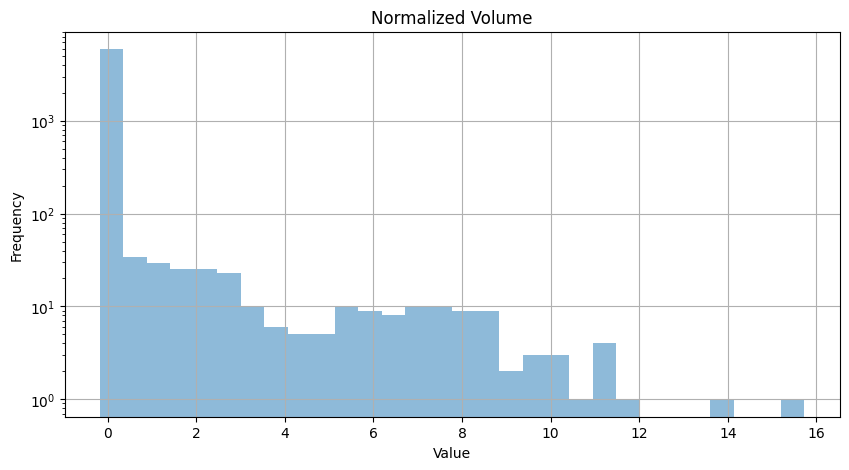

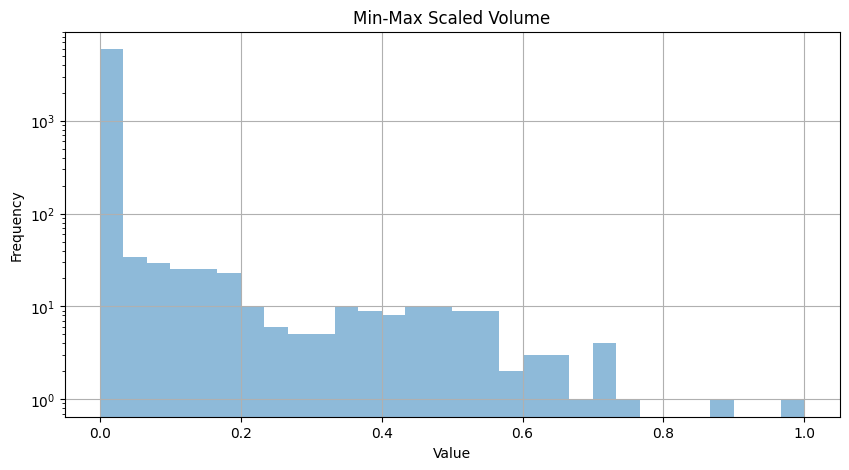

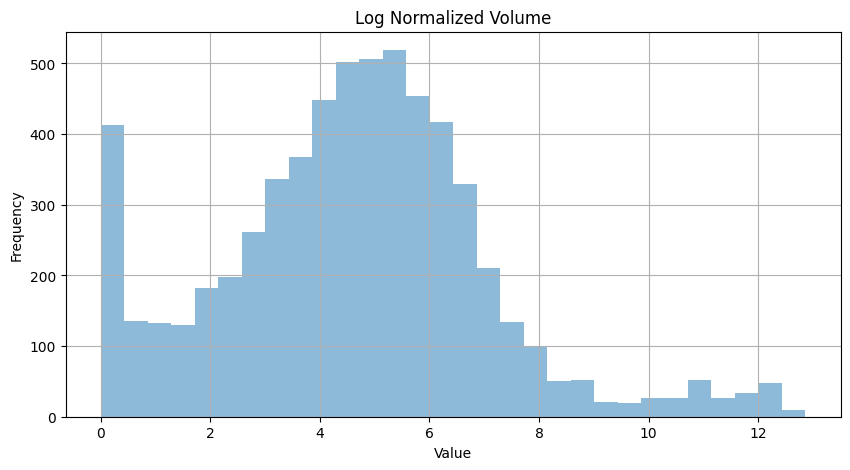

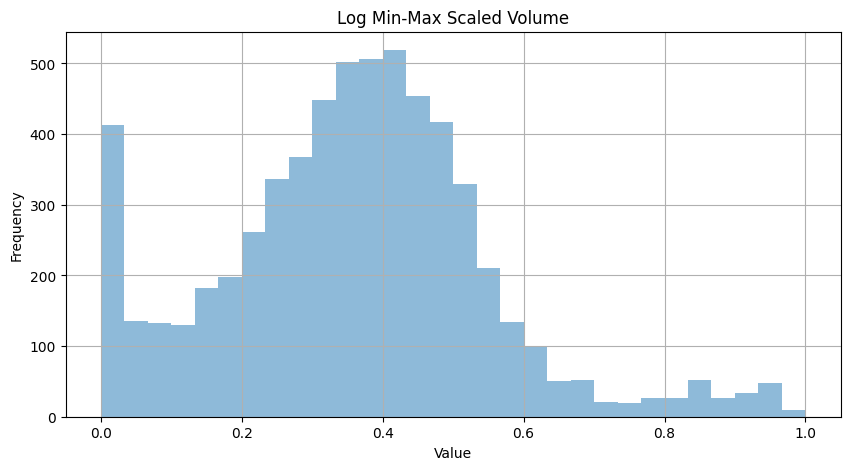

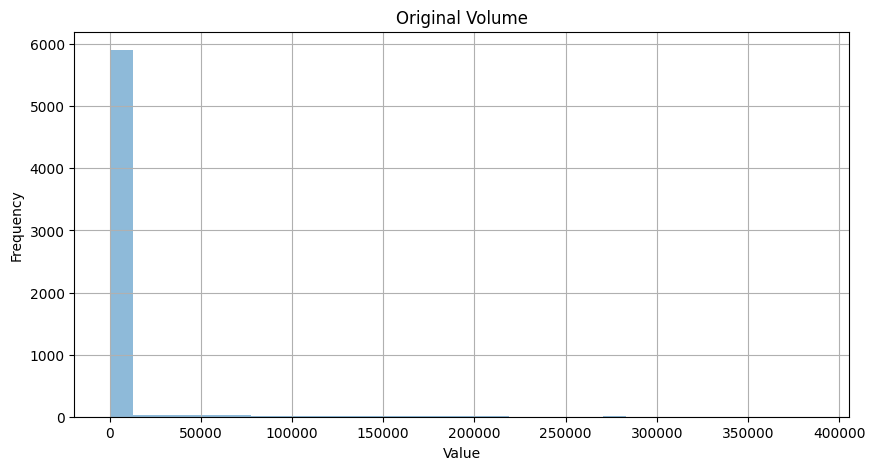

In [29]:
def plot_hist(series: pd.Series, title: str, y_log_scale: bool = False) -> None:
    plt.figure(figsize=(10, 5))
    series.hist(bins=30, alpha=0.5)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    if y_log_scale:
        plt.yscale("log")
    plt.show()


plot_hist(normalize(gold["volume"]), "Normalized Volume", y_log_scale=True)
plot_hist(min_max_scaling(gold["volume"]), "Min-Max Scaled Volume", y_log_scale=True)
plot_hist(log_normalize(gold["volume"]), "Log Normalized Volume")
plot_hist(log_min_max_scaling(gold["volume"]), "Log Min-Max Scaled Volume")
plot_hist(gold["volume"], "Original Volume")

In [30]:
gold["month"] = gold["timestamp"].dt.month
gold["year"] = gold["timestamp"].dt.year
gold = pd.get_dummies(gold, columns=["month", "year"], drop_first=True, dtype=int)
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,day_variation,...,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,-3.5,...,0,0,0,0,0,0,0,0,0,0
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,0.0,...,0,0,0,0,0,0,0,0,0,0
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,0.0,...,0,0,0,0,0,0,0,0,0,0
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...,0.0,...,0,0,0,0,0,0,0,0,0,0


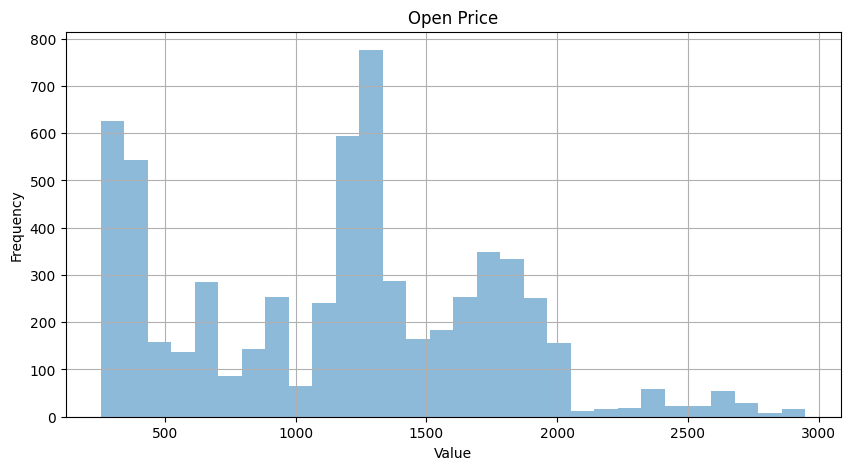

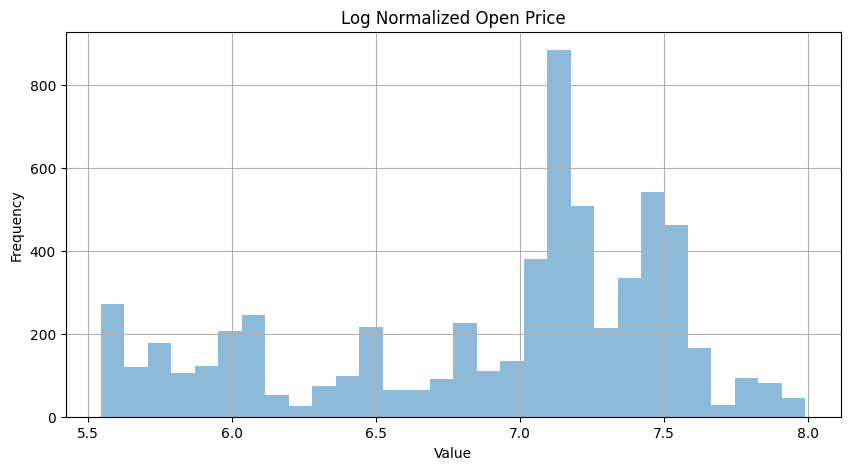

In [31]:
plot_hist(gold["open"], "Open Price")
plot_hist(log_normalize(gold["open"]), "Log Normalized Open Price")

In [32]:
gold["volume"] = log_normalize(gold["volume"])
# gold["open"] = log_normalize(gold["open"])

In [33]:
# gold["max_diff_positive"] = gold["max_diff"].apply(lambda x: 1 if x > 0 else 0)
# gold["max_diff"] = log_normalize(gold["max_diff"])

In [34]:
# gold["day_variation_positive"] = gold["day_variation"].apply(
#     lambda x: 1 if x > 0 else 0
# )
# gold["day_variation"] = log_normalize(gold["day_variation"])

In [35]:
TARGET = "tomorrow_close"
to_drop = [
    "currency",
    "unit",
    # "day_variation",
    # "max_diff",
    "timestamp",
    "close",
    "return",
    "high",
    "low",
    # "volume",
    "open",
]

X = gold.drop(columns=to_drop + [TARGET], axis=1)
y = gold[TARGET]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, shuffle=False
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4917, 42), (1230, 42), (4917,), (1230,))

In [37]:
# X_train = X_train.reset_index(drop=True)
# X_test = X_test.reset_index(drop=True)

# y_train = y_train.reset_index(drop=True)
# y_test = y_test.reset_index(drop=True)

In [38]:
vectorizer = TfidfVectorizer(
    stop_words="english", max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.8
)
tfidf_vectorized_matrix = vectorizer.fit_transform(X_train["headlines"])
TfidfMatrix = pd.DataFrame(
    tfidf_vectorized_matrix.toarray(), columns=vectorizer.get_feature_names_out()
)  # type: ignore
TfidfMatrix.head()

,000,10,100,11,12,14,15,20,2016,25,...,year high,years,yen,yen euro,yield,yields,york,york city,yuan,zone
0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.000000,0.180513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.170773
3,0.0,0.197074,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [39]:
sum_words = TfidfMatrix.sum(axis=0)
words_freq = [
    (word, sum_words.iloc[idx]) for word, idx in vectorizer.vocabulary_.items()
]
sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)

In [40]:
# Extract top N words and their frequencies
words = [word for word, _ in sorted_words[:TOP_N]]
frequencies = [freq for _, freq in sorted_words[:TOP_N]]

tfidf_df = pd.DataFrame(
    {
        "word": words,
        "frequency": frequencies,
    }
)
tfidf_df = tfidf_df.sort_values(by="frequency", ascending=False)
tfidf_df.head(TOP_N)

,word,frequency
0,stocks,194.556765
1,new,172.706557
2,dollar,171.552559
3,oil,164.596594
4,trump,141.059016
5,prices,129.430753
6,china,119.684043
7,profit,116.022783
8,deal,113.633236
9,price,109.322959


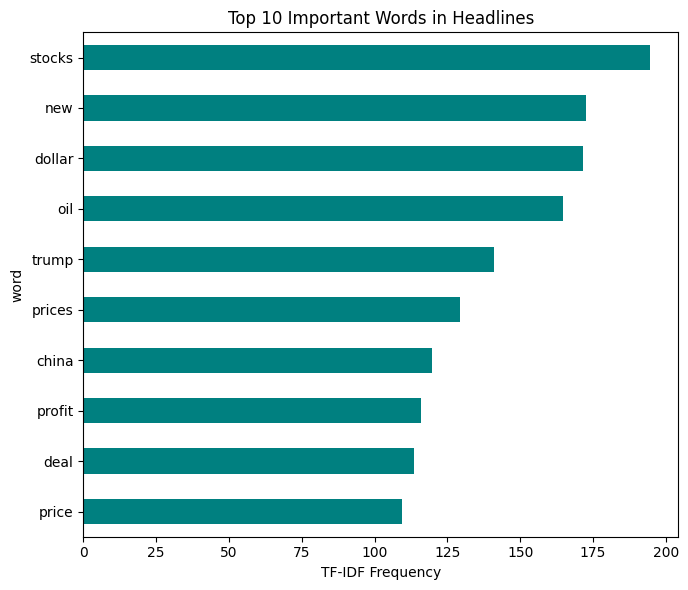

In [41]:
# Plotting using the DataFrame's plot method
tfidf_df.plot(
    x="word",
    y="frequency",
    kind="barh",
    figsize=(7, 6),
    color="teal",
    legend=False,
    title=f"Top {TOP_N} Important Words in Headlines",
)
plt.xlabel("TF-IDF Frequency")
plt.gca().invert_yaxis()  # To have the highest bar at the top
plt.tight_layout()
plt.show()

In [42]:
def contain_word(series: pd.Series, word: str) -> pd.Series:
    """
    Check if a word is contained in the headlines.
    """
    return series.str.contains(word, case=False, na=False).astype(int)


def word_count(series: pd.Series, word: str) -> pd.Series:
    """
    Count the occurrences of a word in the headlines.
    """
    return series.str.lower().str.count(word).fillna(0).astype(int)

In [43]:
for word in tfidf_df["word"]:
    X_train[word] = contain_word(X_train["headlines"], word)
    X_test[word] = contain_word(X_test["headlines"], word)

In [44]:
X_train.drop(columns=["headlines"], inplace=True)
X_test.drop(columns=["headlines"], inplace=True)

In [45]:
X_train.head()

,volume,day_variation,max_diff,price_pca,headlines_count,month_2,month_3,month_4,month_5,month_6,...,stocks,new,dollar,oil,trump,prices,china,profit,deal,price
0,0.000000,0.0,0.0,-1814.153612,13,0,0,0,0,0,...,1,1,0,0,0,0,0,1,0,0
1,0.000000,-3.5,3.5,-1808.843535,14,0,0,0,0,0,...,1,0,0,0,0,0,1,1,1,0
2,0.000000,0.0,0.0,-1807.953661,16,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.098612,0.0,0.0,-1810.353642,9,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,0.000000,0.0,0.0,-1813.553617,7,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0


In [46]:
timestamp_test = gold["timestamp"].iloc[X_test.index]
timestamp_train = gold["timestamp"].iloc[X_train.index]

last_year_in_training_set = timestamp_train.max().year

filtered_test_set_indexes = timestamp_test.dt.year > last_year_in_training_set
filtered_training_set_indexes = timestamp_train.dt.year <= last_year_in_training_set

X_test = X_test.loc[filtered_test_set_indexes]
y_test = y_test.loc[filtered_test_set_indexes]

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
model = Ridge(alpha=0.01)
# model = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     max_features=25,
#     random_state=RANDOM_SEED,
#     n_jobs=-1,
#     verbose=1,
# )
# model= GradientBoostingRegressor(
#     n_estimators=100,
#     max_depth=10,
#     max_features=None,
#     random_state=RANDOM_SEED,
#     verbose=1,
#     alpha=0.01,
# )
# best value if open is log normalized is 4.3
# otherwise 0.01

In [49]:
model.fit(X_train_scaled, y_train)

Ridge(alpha=0.01)

In [50]:
y_pred = model.predict(X_test_scaled)

In [51]:
model.score(X_test_scaled, y_test)

-3.2139261976652405

In [52]:
rmse = root_mean_squared_error(y_test, y_pred)
print("Square root of RMSE:", rmse)

Square root of RMSE: 727.6294283790647


In [53]:
gold[TARGET].describe()

count    6147.000000
mean     1185.444135
std       604.566616
min       255.100000
25%       644.600000
50%      1240.100000
75%      1642.100000
max      3222.200000
Name: tomorrow_close, dtype: float64

In [54]:
# Plot the original target vs predicted values
def plot_target_vs_predicted(
    y_test, y_pred, title="Target vs Predicted", y_label="Target", log_scale=False
):
    plt.figure(figsize=(20, 6))
    plt.scatter(
        y_test.index,
        y_test.to_numpy().reshape(-1, 1),
        label="Original Target",
        color="blue",
        alpha=0.5,
    )
    plt.plot(y_test.index, y_pred, label="Predicted Target", color="red", linewidth=2)
    plt.ylabel(y_label)
    if log_scale:
        plt.yscale("log")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

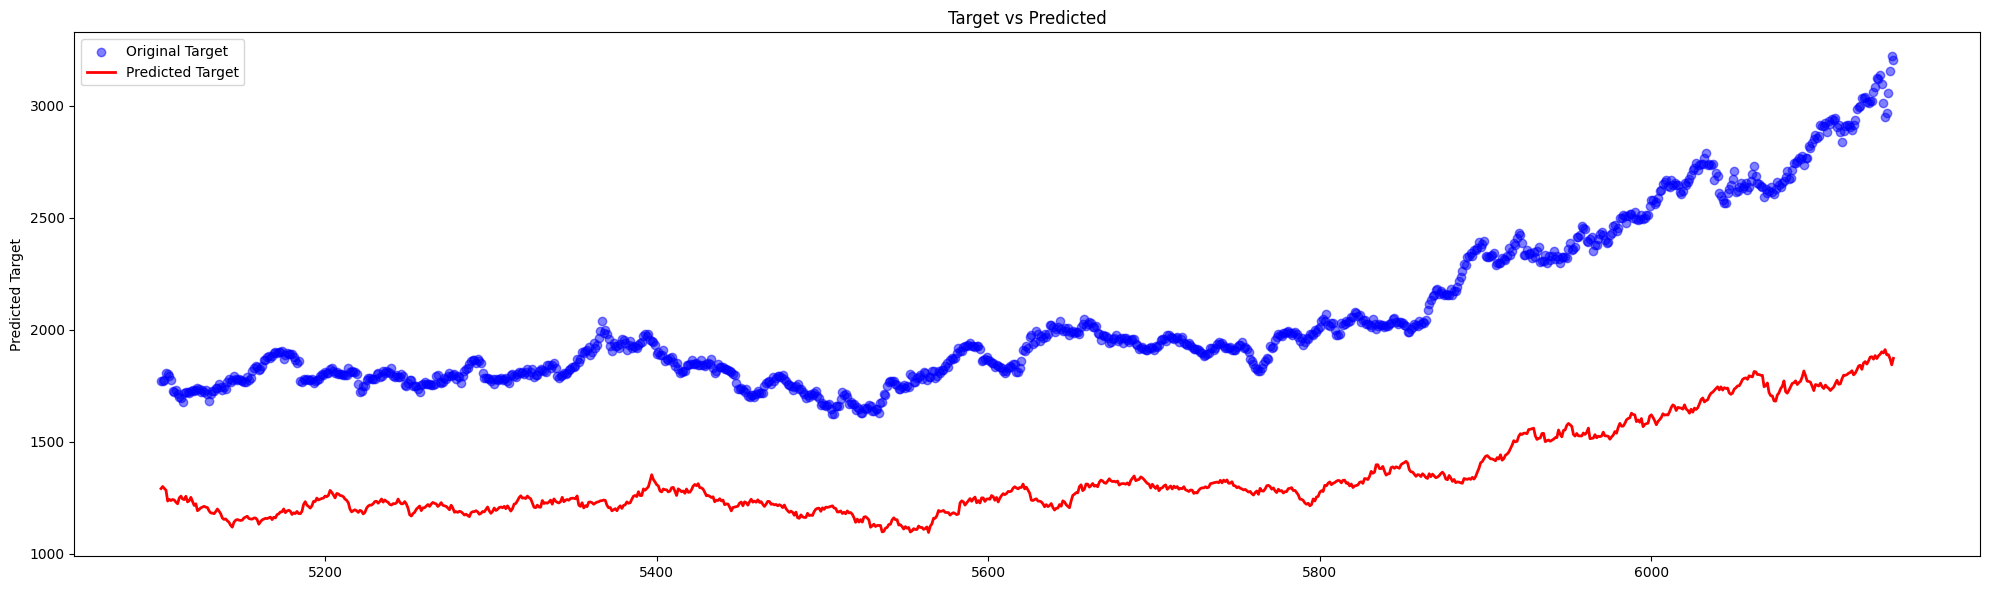

In [55]:
plot_target_vs_predicted(
    y_test, y_pred, title="Target vs Predicted", y_label="Predicted Target"
)

In [56]:
diff_df = pd.DataFrame(
    {
        "Original Target": y_test,
        "Predicted Target": y_pred,
        "Difference": y_pred - y_test,
    },
    index=y_test.index,
)
diff_df

,Original Target,Predicted Target,Difference
5101,1771.1,1291.656575,-479.443425
5102,1773.4,1300.922710,-472.477290
5103,1775.8,1291.986233,-483.813767
5104,1806.7,1284.873277,-521.826723
5105,1804.4,1236.139899,-568.260101
...,...,...,...
6142,2968.4,1888.707062,-1079.692938
6143,3056.5,1889.326303,-1167.173697
6144,3155.2,1871.564265,-1283.635735
6145,3222.2,1844.002302,-1378.197698


In [57]:
diff_df["Difference"].describe()

count    1046.000000
mean     -706.233357
std       175.238091
min     -1378.197698
25%      -801.916011
50%      -656.706818
75%      -575.630382
max      -408.656752
Name: Difference, dtype: float64

In [58]:
diff_df.var()

Original Target     125761.868082
Predicted Target     37814.182237
Difference           30708.388367
dtype: float64

In [59]:
def plot_diff(
    diff: pd.Series, x_axis: pd.Series | None = None, alpha: float = 0.2
) -> None:
    """
    Plot the difference between original and predicted target.
    """
    x_axis = x_axis if x_axis is not None else diff.index
    plt.figure(figsize=(20, 6))
    plt.scatter(
        x_axis, diff, label="Difference", color="blue", linewidth=2, alpha=alpha
    )

    # # Add color zones for each year
    if "datetime" in str(x_axis.dtype):
        unique_years = x_axis.sort_values().dt.year.unique()
        for year in unique_years:
            start_date = pd.Timestamp(f"{year}-01-01")
            end_date = pd.Timestamp(f"{year}-12-31")
            plt.axvspan(
                start_date,
                end_date,
                color="gray",
                alpha=0.1 if year % 2 == 0 else 0.2,
                label=f"{year} Zone" if year == unique_years[0] else None,
            )
            plt.xlabel("Timestamp")

    plt.axhline(y=0, color="red", linestyle="--", label="Zero Line")
    plt.title("Difference between Original and Predicted Target")
    plt.ylabel("Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

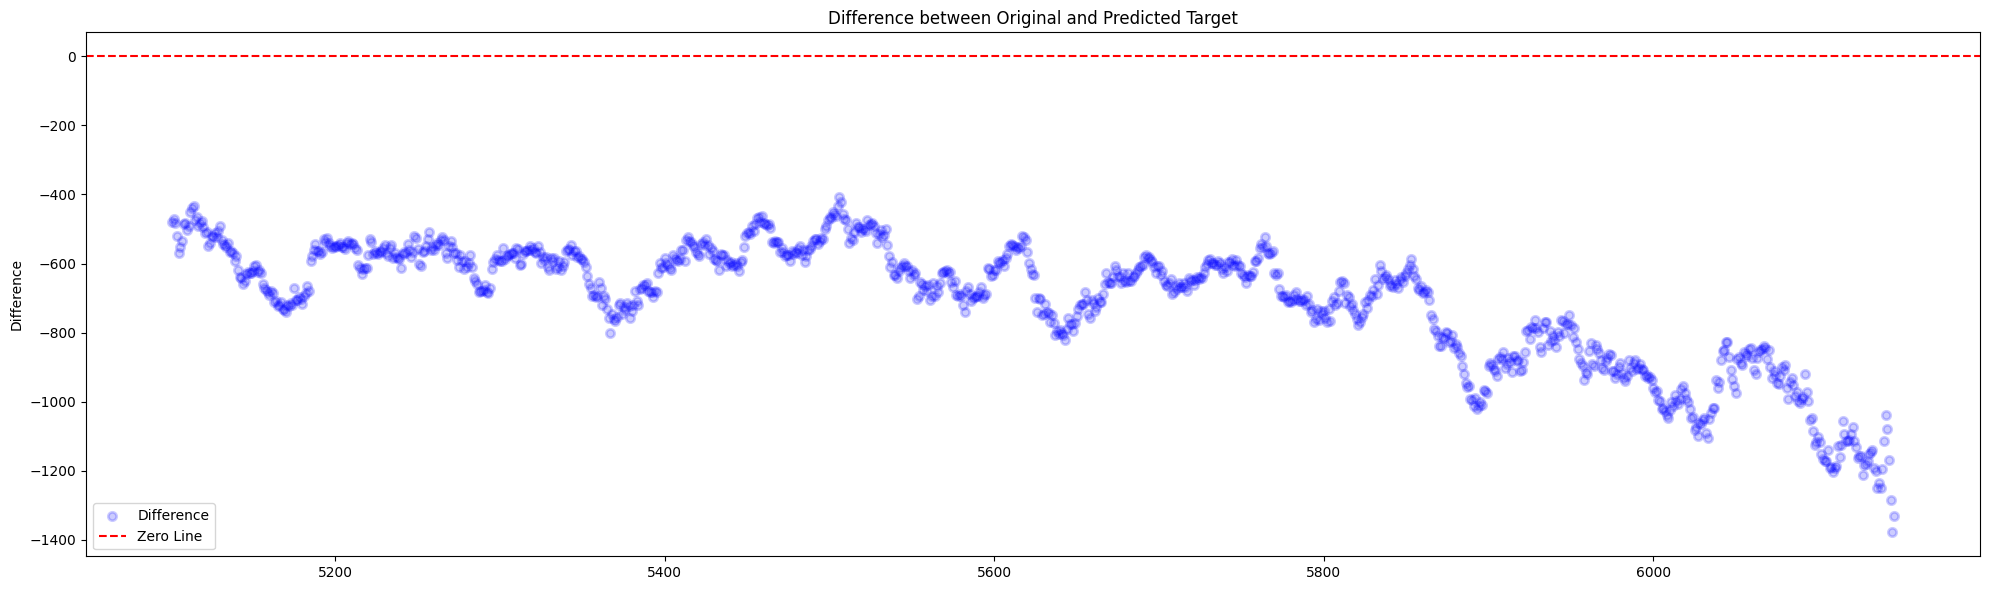

In [60]:
plot_diff(diff_df["Difference"])

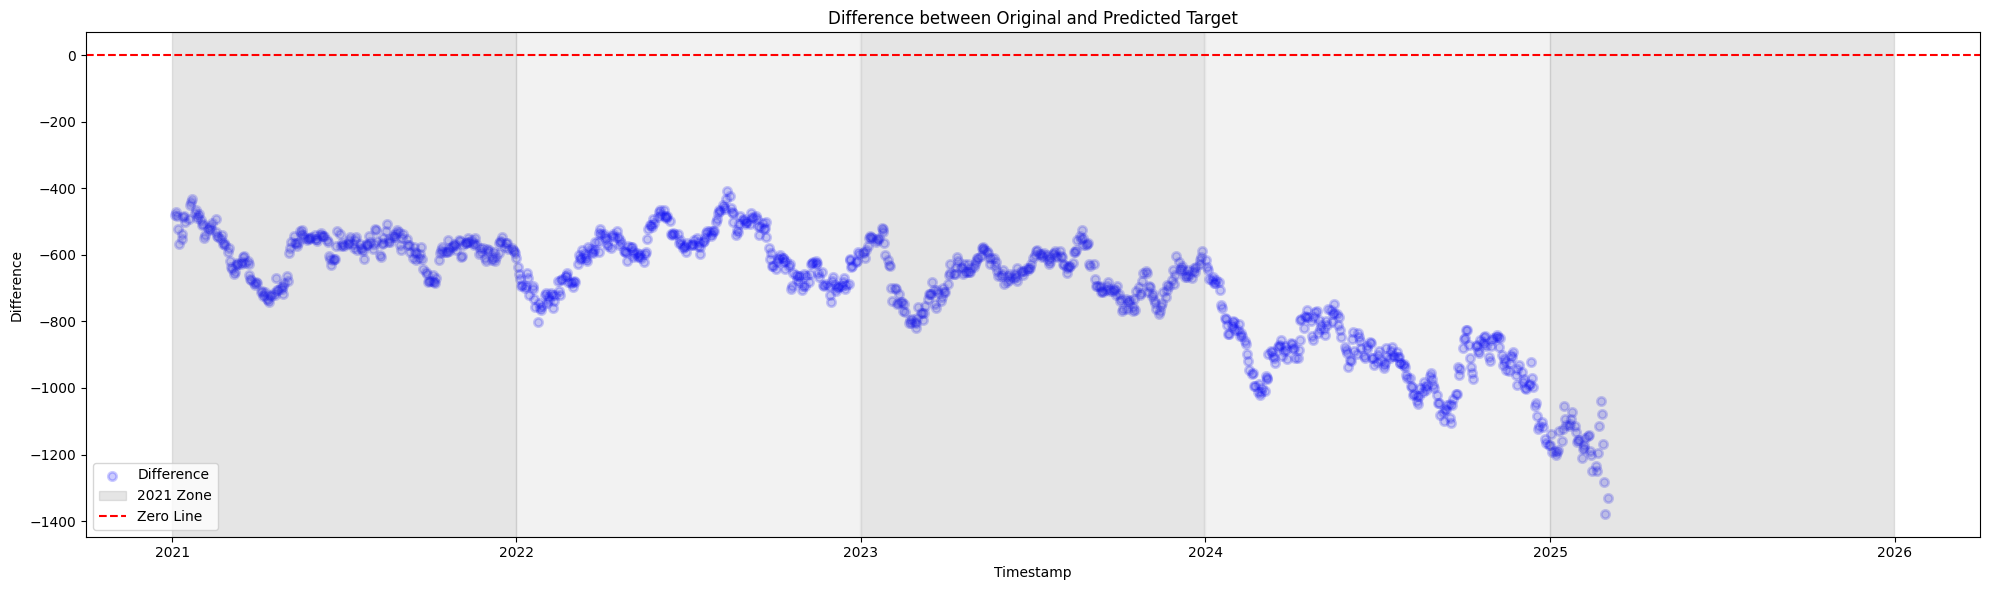

In [61]:
plot_diff(
    diff_df["Difference"],
    timestamp_test.loc[filtered_test_set_indexes],
)

In [62]:
y_train_pred = model.predict(X_train_scaled)

In [63]:
from sklearn.metrics import r2_score


r2_score(y_train, y_train_pred)

0.9888809062969993

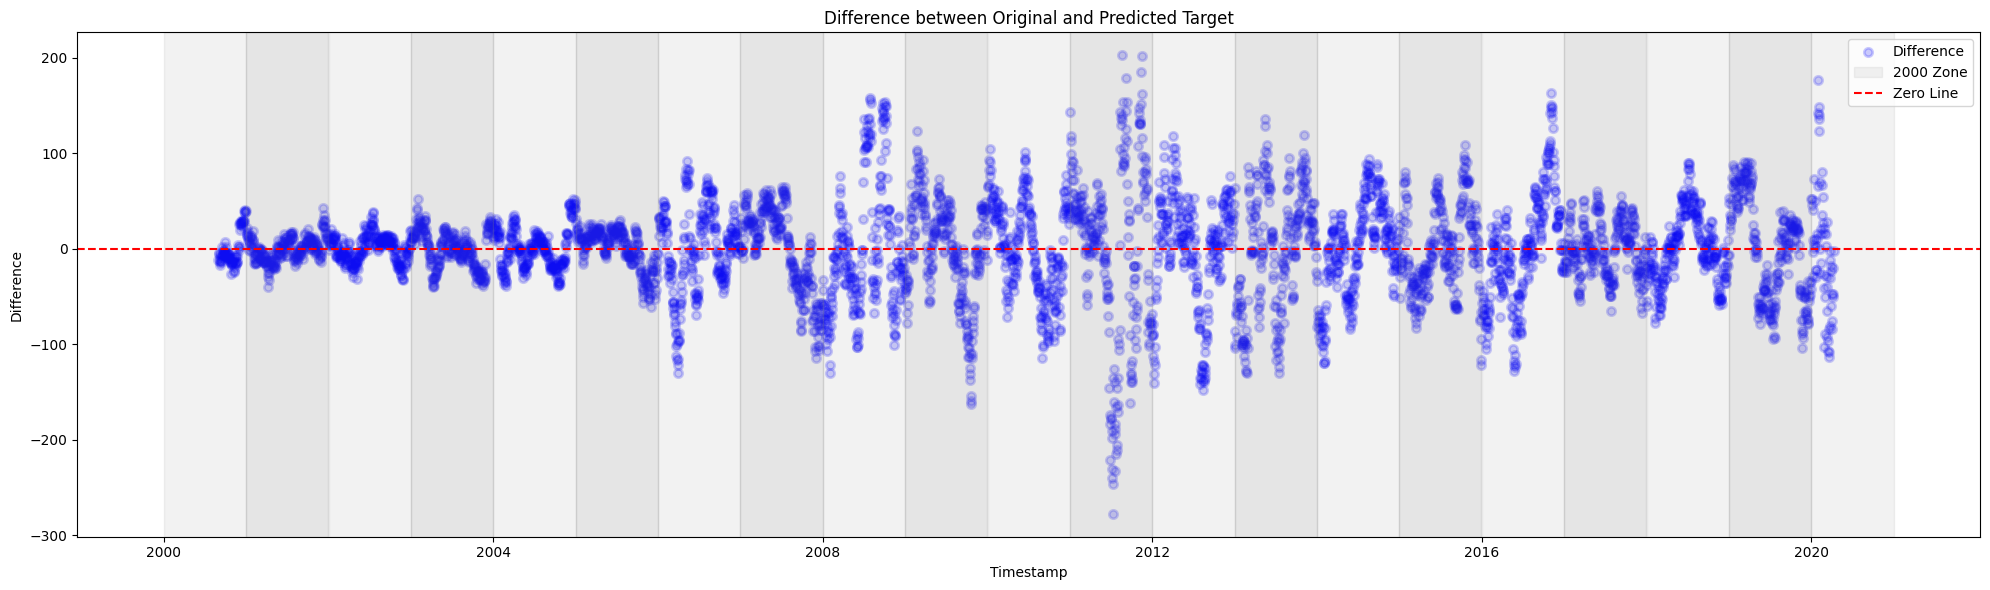

In [64]:
plot_diff(
    diff=y_train_pred - y_train,
    x_axis=timestamp_train.loc[filtered_training_set_indexes],
)

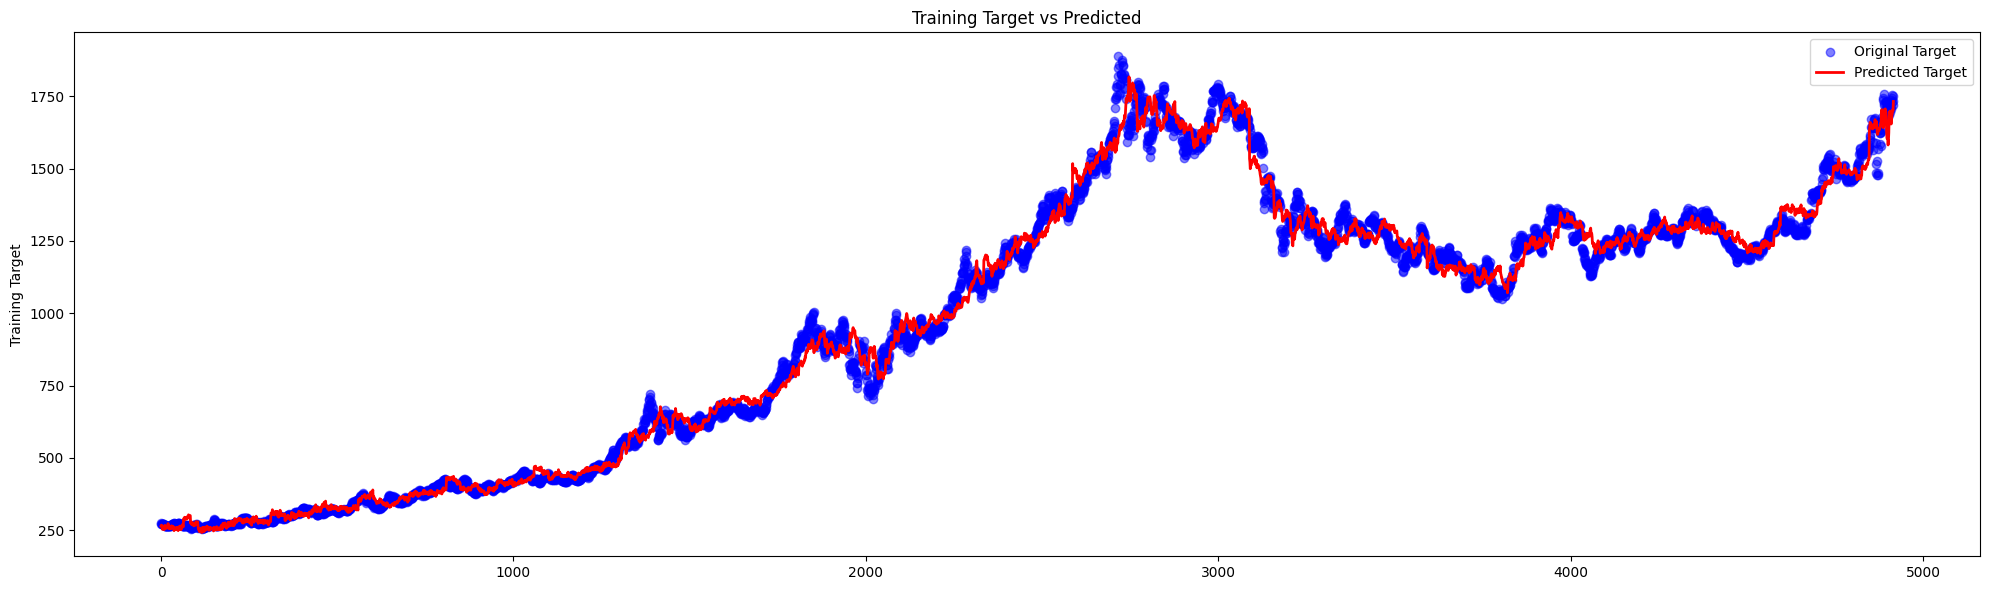

In [65]:
plot_target_vs_predicted(
    y_train,
    y_train_pred,
    title="Training Target vs Predicted",
    y_label="Training Target",
)

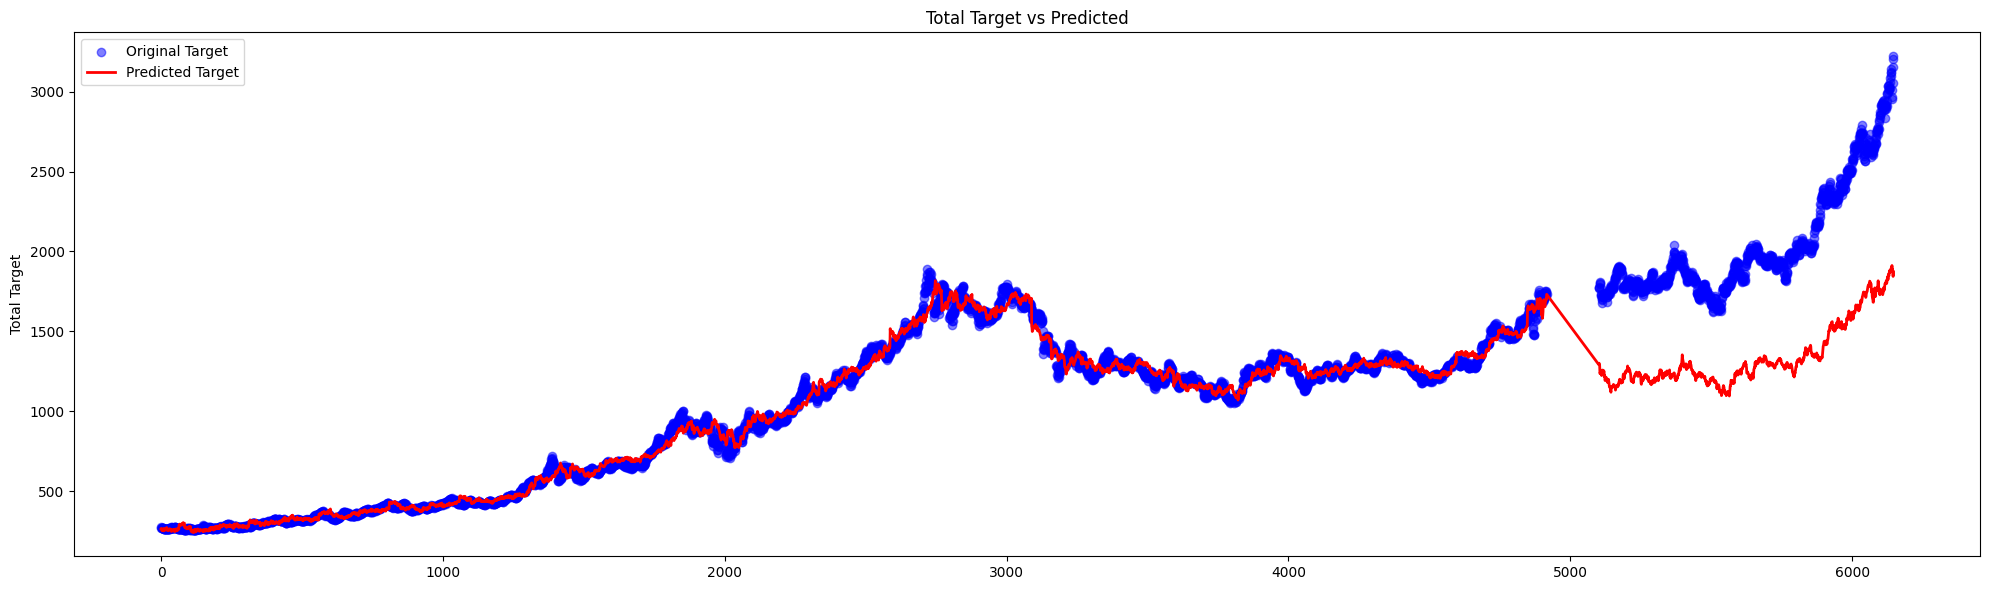

In [66]:
y_reconstructed = y[y.index.isin(X_test.index) | y.index.isin(X_train.index)].copy()
X_reconstructed = pd.concat([X_train, X_test])
X_reconstructed_scaled = scaler.transform(X_reconstructed)
y_total_pred = model.predict(X_reconstructed_scaled)
plot_target_vs_predicted(
    y_reconstructed,
    y_total_pred,
    title="Total Target vs Predicted",
    y_label="Total Target",
)

In [67]:
model.score(X_reconstructed_scaled, y_reconstructed)

0.7380624606863762

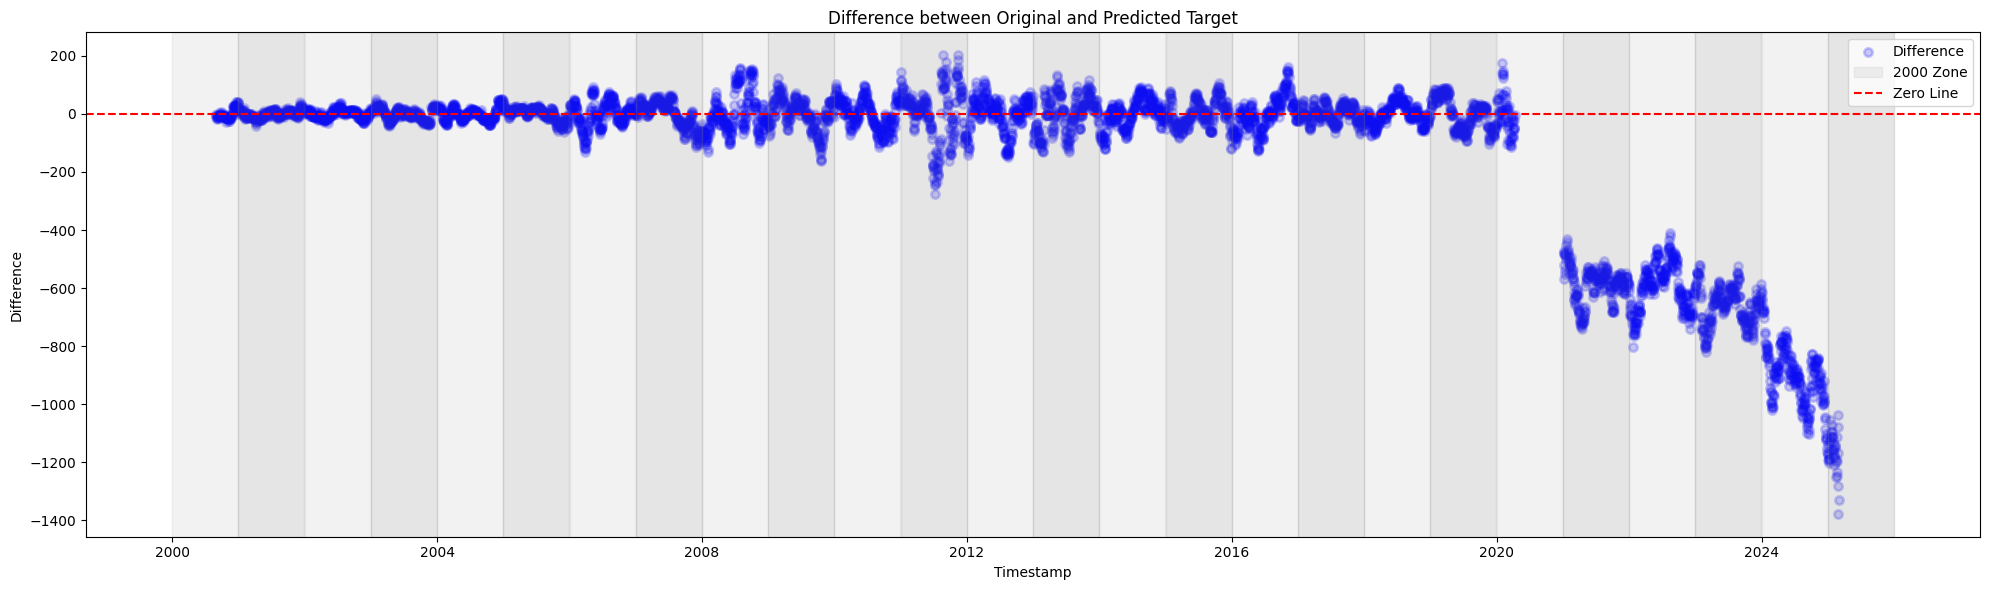

In [68]:
plot_diff(
    y_total_pred - y_reconstructed,
    x_axis=gold["timestamp"].loc[X_reconstructed.index],
)